# Week 3 — Day 4  
## Comparing Classification Models

This notebook compares four supervised classification algorithms on the COVID-19 individual testing dataset:

- Decision Tree
- Random Forest
- k-Nearest Neighbors
- Linear Support Vector Machine

The task is to predict whether a tested individual received a positive or negative result using the recorded symptoms, age group, gender, and test indication.

The notebook follows one consistent workflow: inspect the data, prepare the target and features, create a reproducible train-test split, preprocess the predictors, train the models, and compare their results using metrics suited to an imbalanced classification problem.

## 1. Imports and Reproducibility

The same random state is used throughout the notebook so the sample, data split, and model results can be reproduced.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 2. Load the Dataset

The notebook is stored in the same folder as the CSV file, so the dataset is loaded directly from its fixed filename.

In [2]:
DATA_PATH = "corona_tested_individuals_ver_006.english.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


## 3. Dataset Structure

The dataset contains one row for each recorded test and includes the test date, five symptom indicators, the test result, age group, gender, and the reason for testing.

In [3]:
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print()
print(df_raw.columns.tolist())

Rows: 278,848
Columns: 10

['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'corona_result', 'age_60_and_above', 'gender', 'test_indication']


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 21.3 MB


In [5]:
inspection = pd.DataFrame({
    "data_type": df_raw.dtypes.astype(str),
    "missing_values": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique(dropna=False)
})

inspection

,data_type,missing_values,missing_percent,unique_values
test_date,str,0,0.00,51
cough,float64,252,0.09,3
fever,float64,252,0.09,3
sore_throat,float64,1,0.00,3
shortness_of_breath,float64,1,0.00,3
head_ache,float64,1,0.00,3
corona_result,str,0,0.00,3
age_60_and_above,str,127320,45.66,3
gender,str,19563,7.02,3
test_indication,str,0,0.00,3


Repeated rows are reported but not removed automatically. In this dataset, two individuals can have the same symptoms and demographic values, so identical-looking records are not necessarily accidental duplicates.

In [6]:
print(f"Repeated rows: {df_raw.duplicated().sum():,}")

Repeated rows: 272,207


### Duplicate Records

The inspection reports 272,207 repeated rows. They are kept because the dataset does not include a unique person or test identifier. Two tests can therefore have the same date, symptoms, demographic fields, result, and test indication without being confirmed duplicate entries. Removing them based only on identical column values could discard valid records.

## 4. Clean the Recorded Values

Column names and text values are standardized to lowercase. Missing demographic values and text entries such as `None` are represented as `unknown`.

The symptom columns are converted to binary integers. Any missing symptom value is treated as `0`, which matches the dataset's indicator format where `1` means the symptom was recorded and `0` means it was not recorded.

In [7]:
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower()

text_columns = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .str.lower()
        .fillna("unknown")
        .replace({
            "none": "unknown",
            "nan": "unknown",
            "": "unknown"
        })
    )

symptom_columns = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

for column in symptom_columns:
    df[column] = (
        pd.to_numeric(df[column], errors="coerce")
        .fillna(0)
        .clip(0, 1)
        .astype("int8")
    )

df["test_date"] = pd.to_datetime(df["test_date"], errors="coerce")

df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0,0,0,0,0,negative,unknown,female,other
1,2020-04-30,1,0,0,0,0,negative,unknown,female,other
2,2020-04-30,0,1,0,0,0,negative,unknown,male,other
3,2020-04-30,1,0,0,0,0,negative,unknown,female,other
4,2020-04-30,1,0,0,0,0,negative,unknown,male,other


## 5. Define the Binary Target

The prediction task is binary, so only records labeled `positive` or `negative` are used. Records labeled `other` do not represent either class and are excluded from modeling.

The target is encoded as:

- `0` = negative
- `1` = positive

In [8]:
result_counts_before_filtering = df["corona_result"].value_counts(dropna=False)
result_counts_before_filtering

corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: Int64

In [9]:
df = df[df["corona_result"].isin(["positive", "negative"])].copy()
df["target"] = (
    df["corona_result"]
    .map({"negative": 0, "positive": 1})
    .astype("int8")
)

print(f"Rows kept for binary classification: {len(df):,}")
print(f"Rows excluded: {len(df_raw) - len(df):,}")

Rows kept for binary classification: 274,956
Rows excluded: 3,892


### Binary Target Summary

The original dataset contains 260,227 negative results, 14,729 positive results, and 3,892 records labeled `other`.

After removing `other`, 274,956 records remain for the binary classification task. The excluded records account for about 1.4% of the original dataset.

## 6. Target Distribution

The class distribution is inspected before training. When negative cases are much more common than positive cases, accuracy can look high even if a model performs poorly on positive cases. For that reason, the final comparison also includes balanced accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [10]:
target_distribution = pd.DataFrame({
    "count": df["corona_result"].value_counts(),
    "percent": (df["corona_result"].value_counts(normalize=True) * 100).round(2)
})

target_distribution

,count,percent
corona_result,,
negative,260227,94.64
positive,14729,5.36


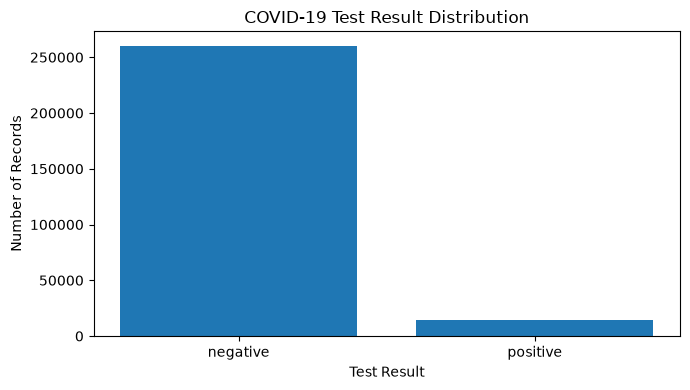

In [11]:
target_counts = (
    df["corona_result"]
    .value_counts()
    .reindex(["negative", "positive"])
)

plt.figure(figsize=(7, 4))
plt.bar(target_counts.index, target_counts.values)
plt.title("COVID-19 Test Result Distribution")
plt.xlabel("Test Result")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

### Class Balance

Negative results represent 94.64% of the binary target, while positive results represent 5.36%.

This is a strongly imbalanced classification problem. A model can achieve high accuracy by favoring the negative class, so positive-class recall, precision, F1-score, balanced accuracy, and PR-AUC are necessary for a meaningful comparison.

## 7. Symptom Rates by Test Result

The average of a binary symptom column is the proportion of records in which that symptom equals `1`. Comparing these rates across positive and negative cases gives an initial view of which symptoms may help the classifiers.

In [12]:
symptom_rates = (
    df.groupby("corona_result")[symptom_columns]
    .mean()
    .T
    .mul(100)
    .round(2)
)

symptom_rates

corona_result,negative,positive
cough,13.44,44.70
fever,6.08,37.74
sore_throat,0.14,10.36
shortness_of_breath,0.15,7.90
head_ache,0.06,15.17


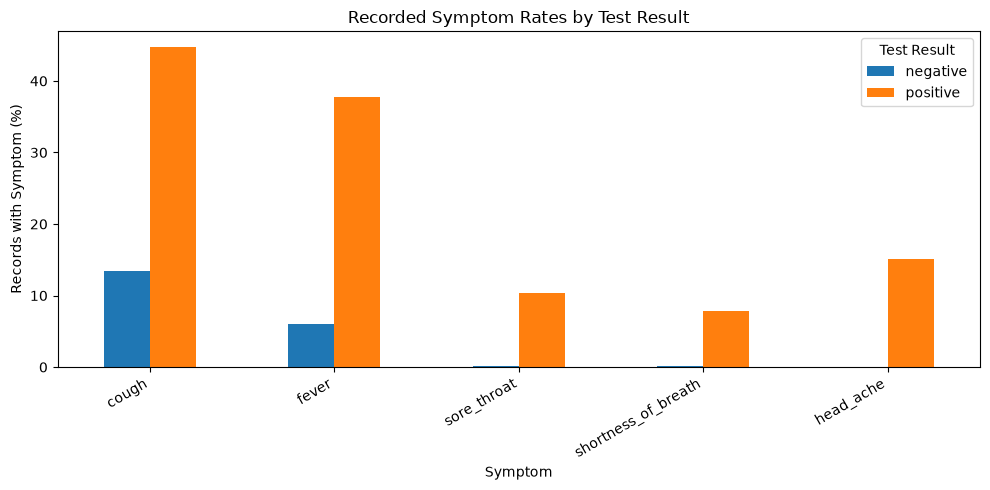

In [13]:
symptom_rates.plot(kind="bar", figsize=(10, 5))
plt.title("Recorded Symptom Rates by Test Result")
plt.xlabel("Symptom")
plt.ylabel("Records with Symptom (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Test Result")
plt.tight_layout()
plt.show()

### Symptom Comparison

Every recorded symptom appears more frequently among positive cases.

Cough is recorded for 44.70% of positive cases compared with 13.44% of negative cases. Fever shows a similar difference, rising from 6.08% among negative cases to 37.74% among positive cases.

The largest relative differences appear in headache, sore throat, and shortness of breath. These symptoms are uncommon among negative cases but occur in 15.17%, 10.36%, and 7.90% of positive cases, respectively.

## 8. Select the Modeling Features

The five symptoms, age group, gender, and test indication are used as predictors.

`test_date` is excluded because the goal is to compare classifiers using the individual's recorded characteristics. The result column is also excluded because it is the target itself.

In [14]:
feature_columns = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "age_60_and_above",
    "gender",
    "test_indication"
]

numeric_features = symptom_columns
categorical_features = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

X_full = df[feature_columns].copy()
y_full = df["target"].copy()

print(f"Available modeling rows: {len(X_full):,}")
print(f"Predictors: {len(feature_columns)}")

Available modeling rows: 274,956
Predictors: 8


## 9. Create a Reproducible Modeling Sample

Exact k-nearest neighbors prediction becomes expensive on very large datasets because every test record must be compared with many training records.

To keep all four models on the same data and make the notebook practical to run on a standard laptop, the comparison uses a reproducible stratified sample of at most 30,000 records. If the cleaned dataset contains fewer records, all of them are used.

Stratification keeps the original positive-to-negative ratio in the modeling sample.

In [15]:
MAX_MODEL_ROWS = 30000

if len(df) > MAX_MODEL_ROWS:
    model_df, _ = train_test_split(
        df,
        train_size=MAX_MODEL_ROWS,
        random_state=RANDOM_STATE,
        stratify=df["target"]
    )
else:
    model_df = df.copy()

model_df = model_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X = model_df[feature_columns].copy()
y = model_df["target"].copy()

sample_distribution = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})

sample_distribution.index = ["negative", "positive"]
sample_distribution

,count,percent
negative,28393,94.64
positive,1607,5.36


### Modeling Sample

The stratified sample contains 30,000 records: 28,393 negative cases and 1,607 positive cases. Its 94.64% to 5.36% class distribution matches the cleaned dataset.

Using the same sample for all four classifiers keeps the comparison consistent while allowing k-NN to run in a practical amount of time.

## 10. Train-Test Split

Twenty percent of the modeling data is reserved for final testing. The split is stratified so both sets retain the same class balance.

The test set is not used during preprocessing or training.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    "training_count": y_train.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index()
})

split_summary.index = ["negative", "positive"]
split_summary

,training_count,test_count
negative,22714,5679
positive,1286,321


### Split Summary

The training set contains 24,000 records, including 1,286 positive cases. The test set contains 6,000 records, including 321 positive cases.

The positive-class proportion remains the same in both sets because the split is stratified.

## 11. Preprocessing

The symptom indicators are standardized because k-NN and SVM are affected by feature scale.

The categorical predictors are transformed with one-hot encoding. Unknown categories that appear later are ignored instead of causing an error.

Preprocessing is placed inside each model pipeline, so it is fitted only on the training data.

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tran

## 12. Build and Train the Classifiers

Each model receives the same training data and the same preprocessing steps.

The tree-based models and the SVM use class weighting to reduce the effect of class imbalance. The Decision Tree is restricted to a moderate depth, while the Random Forest combines many trees. k-NN uses distance weighting so closer neighbors contribute more strongly.

In [18]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "k-NN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000
    )
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

print("All four classifiers were trained successfully.")

All four classifiers were trained successfully.


## 13. Majority-Class Baseline

A majority-class baseline predicts the most common class for every record. Its accuracy shows why accuracy alone is not enough when the target is imbalanced.

In [19]:
majority_class = y_train.mode().iloc[0]
baseline_predictions = np.full(len(y_test), majority_class)

baseline_summary = pd.Series({
    "Accuracy": accuracy_score(y_test, baseline_predictions),
    "Balanced Accuracy": balanced_accuracy_score(y_test, baseline_predictions),
    "Precision": precision_score(y_test, baseline_predictions, zero_division=0),
    "Recall": recall_score(y_test, baseline_predictions, zero_division=0),
    "F1": f1_score(y_test, baseline_predictions, zero_division=0)
})

baseline_summary.round(4)

Accuracy             0.9465
Balanced Accuracy    0.5000
Precision            0.0000
Recall               0.0000
F1                   0.0000
dtype: float64

### Baseline Result

The majority-class baseline reaches 94.65% accuracy by predicting every test result as negative. However, its positive-class precision, recall, and F1-score are all 0.

This confirms that accuracy alone would give a misleading picture of performance on this dataset.

## 14. Evaluate the Models

The comparison uses several complementary metrics:

- **Accuracy:** overall proportion of correct predictions
- **Balanced Accuracy:** average recall across both classes
- **Precision:** reliability of positive predictions
- **Recall:** proportion of actual positive cases detected
- **Specificity:** proportion of actual negative cases detected
- **F1-score:** balance between precision and recall
- **ROC-AUC:** ability to rank positive cases above negative cases
- **PR-AUC:** precision-recall performance for the positive class

In [20]:
results = []
predictions = {}
decision_scores = {}

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC": average_precision_score(y_test, y_score)
    })

    predictions[name] = y_pred
    decision_scores[name] = y_score

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("F1", ascending=False)
)

results_df.round(4)

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC
Model,,,,,,,,
k-NN,0.9692,0.7927,0.7764,0.5950,0.9903,0.6737,0.9081,0.6758
Linear SVM,0.9255,0.8637,0.4009,0.7944,0.9329,0.5329,0.9239,0.6741
Random Forest,0.9192,0.8882,0.3848,0.8536,0.9229,0.5305,0.9249,0.7092
Decision Tree,0.8872,0.8699,0.3027,0.8505,0.8892,0.4464,0.9194,0.6733


### Model Comparison Findings

k-NN achieves the highest F1-score at 0.6737. It also has the highest precision at 0.7764 and the highest overall accuracy at 0.9692. Its main limitation is recall: it detects 59.50% of the positive cases.

Random Forest produces the highest recall at 0.8536, the highest balanced accuracy at 0.8882, and the highest PR-AUC at 0.7092. It detects more positive cases than k-NN, but its precision falls to 0.3848 because it produces more false positive predictions.

Linear SVM gives a similar compromise, with 0.7944 recall and a 0.5329 F1-score. Decision Tree also reaches high recall at 0.8505, but its lower precision of 0.3027 produces the weakest F1-score among the four models.

The results show two different strengths: k-NN provides the best balance between precision and recall, while Random Forest is better when detecting as many positive cases as possible is the main priority.

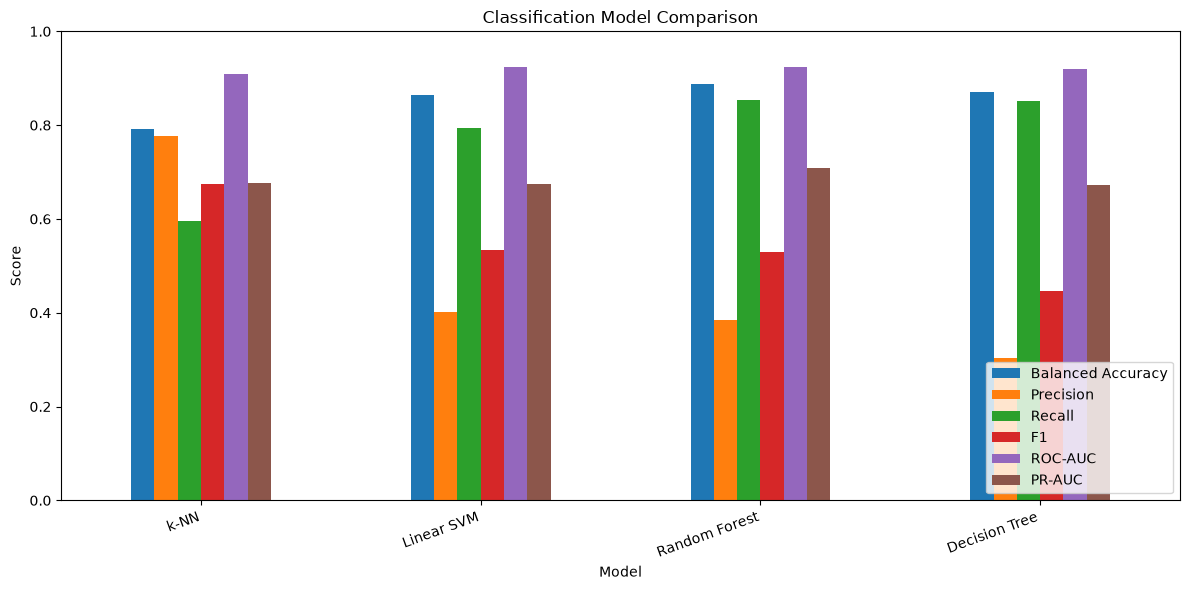

In [21]:
results_df.plot(
    kind="bar",
    y=[
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    figsize=(12, 6)
)
plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 15. Confusion Matrices

The confusion matrices show correct and incorrect predictions for both classes. They make the trade-off between missed positive cases and false positive predictions visible.

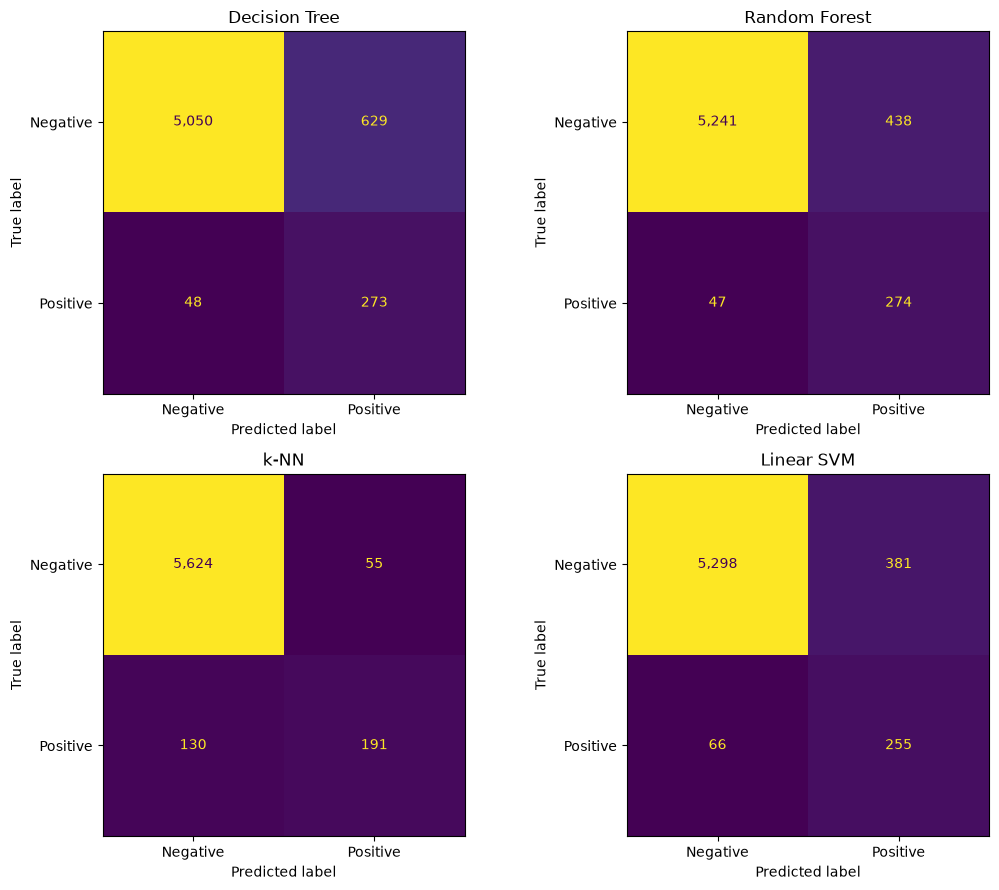

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for axis, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        labels=[0, 1],
        display_labels=["Negative", "Positive"],
        values_format=",",
        colorbar=False,
        ax=axis
    )
    axis.set_title(name)

plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

On the 6,000-record test set:

- **Decision Tree** detects 273 of the 321 positive cases and misses 48, but it incorrectly labels 629 negative cases as positive.
- **Random Forest** detects 274 positive cases and misses 47, while producing 438 false positives.
- **k-NN** produces only 55 false positives, but it detects 191 positive cases and misses 130.
- **Linear SVM** detects 255 positive cases and misses 66, with 381 false positives.

These counts explain the metric trade-off. k-NN has the strongest precision and specificity, while Random Forest has the strongest positive-case recall.

## 16. Classification Reports

The reports provide precision, recall, and F1-score separately for negative and positive cases.

In [23]:
for name, y_pred in predictions.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(
        classification_report(
            y_test,
            y_pred,
            labels=[0, 1],
            target_names=["Negative", "Positive"],
            digits=4,
            zero_division=0
        )
    )

Decision Tree
              precision    recall  f1-score   support

    Negative     0.9906    0.8892    0.9372      5679
    Positive     0.3027    0.8505    0.4464       321

    accuracy                         0.8872      6000
   macro avg     0.6466    0.8699    0.6918      6000
weighted avg     0.9538    0.8872    0.9109      6000

Random Forest
              precision    recall  f1-score   support

    Negative     0.9911    0.9229    0.9558      5679
    Positive     0.3848    0.8536    0.5305       321

    accuracy                         0.9192      6000
   macro avg     0.6880    0.8882    0.7431      6000
weighted avg     0.9587    0.9192    0.9330      6000

k-NN
              precision    recall  f1-score   support

    Negative     0.9774    0.9903    0.9838      5679
    Positive     0.7764    0.5950    0.6737       321

    accuracy                         0.9692      6000
   macro avg     0.8769    0.7927    0.8288      6000
weighted avg     0.9667    0.9692    0.96

## 17. ROC Curves

The ROC curve compares the true-positive rate with the false-positive rate across decision thresholds. Curves closer to the upper-left corner indicate stronger ranking performance.

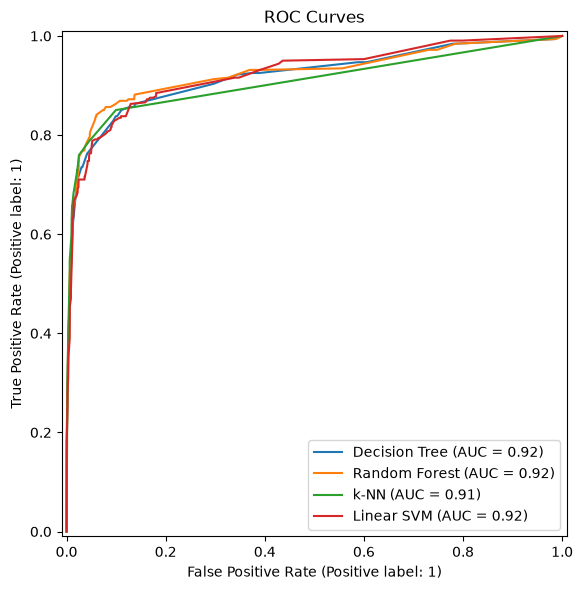

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_score in decision_scores.items():
    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=name,
        ax=ax
    )

plt.title("ROC Curves")
plt.tight_layout()
plt.show()

## 18. Precision-Recall Curves

Precision-recall curves focus on the positive class and are especially useful when positive cases are less common than negative cases.

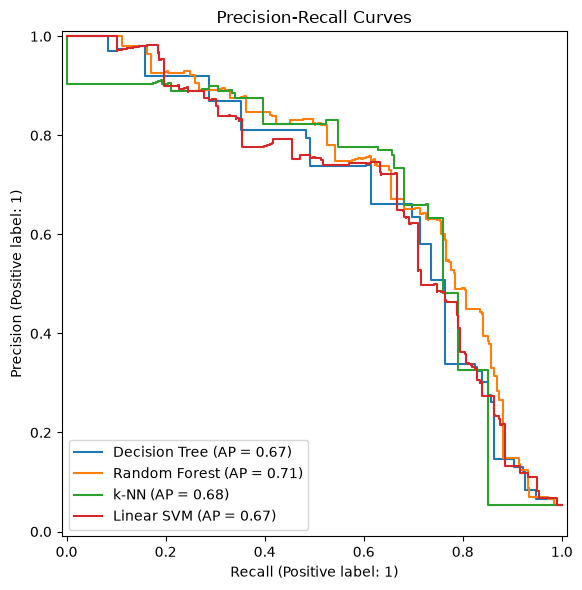

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_score in decision_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=name,
        ax=ax
    )

plt.title("Precision-Recall Curves")
plt.tight_layout()
plt.show()

## 19. Decision Tree Structure

The first three levels of the Decision Tree are displayed to show its main decision rules without making the figure too crowded.

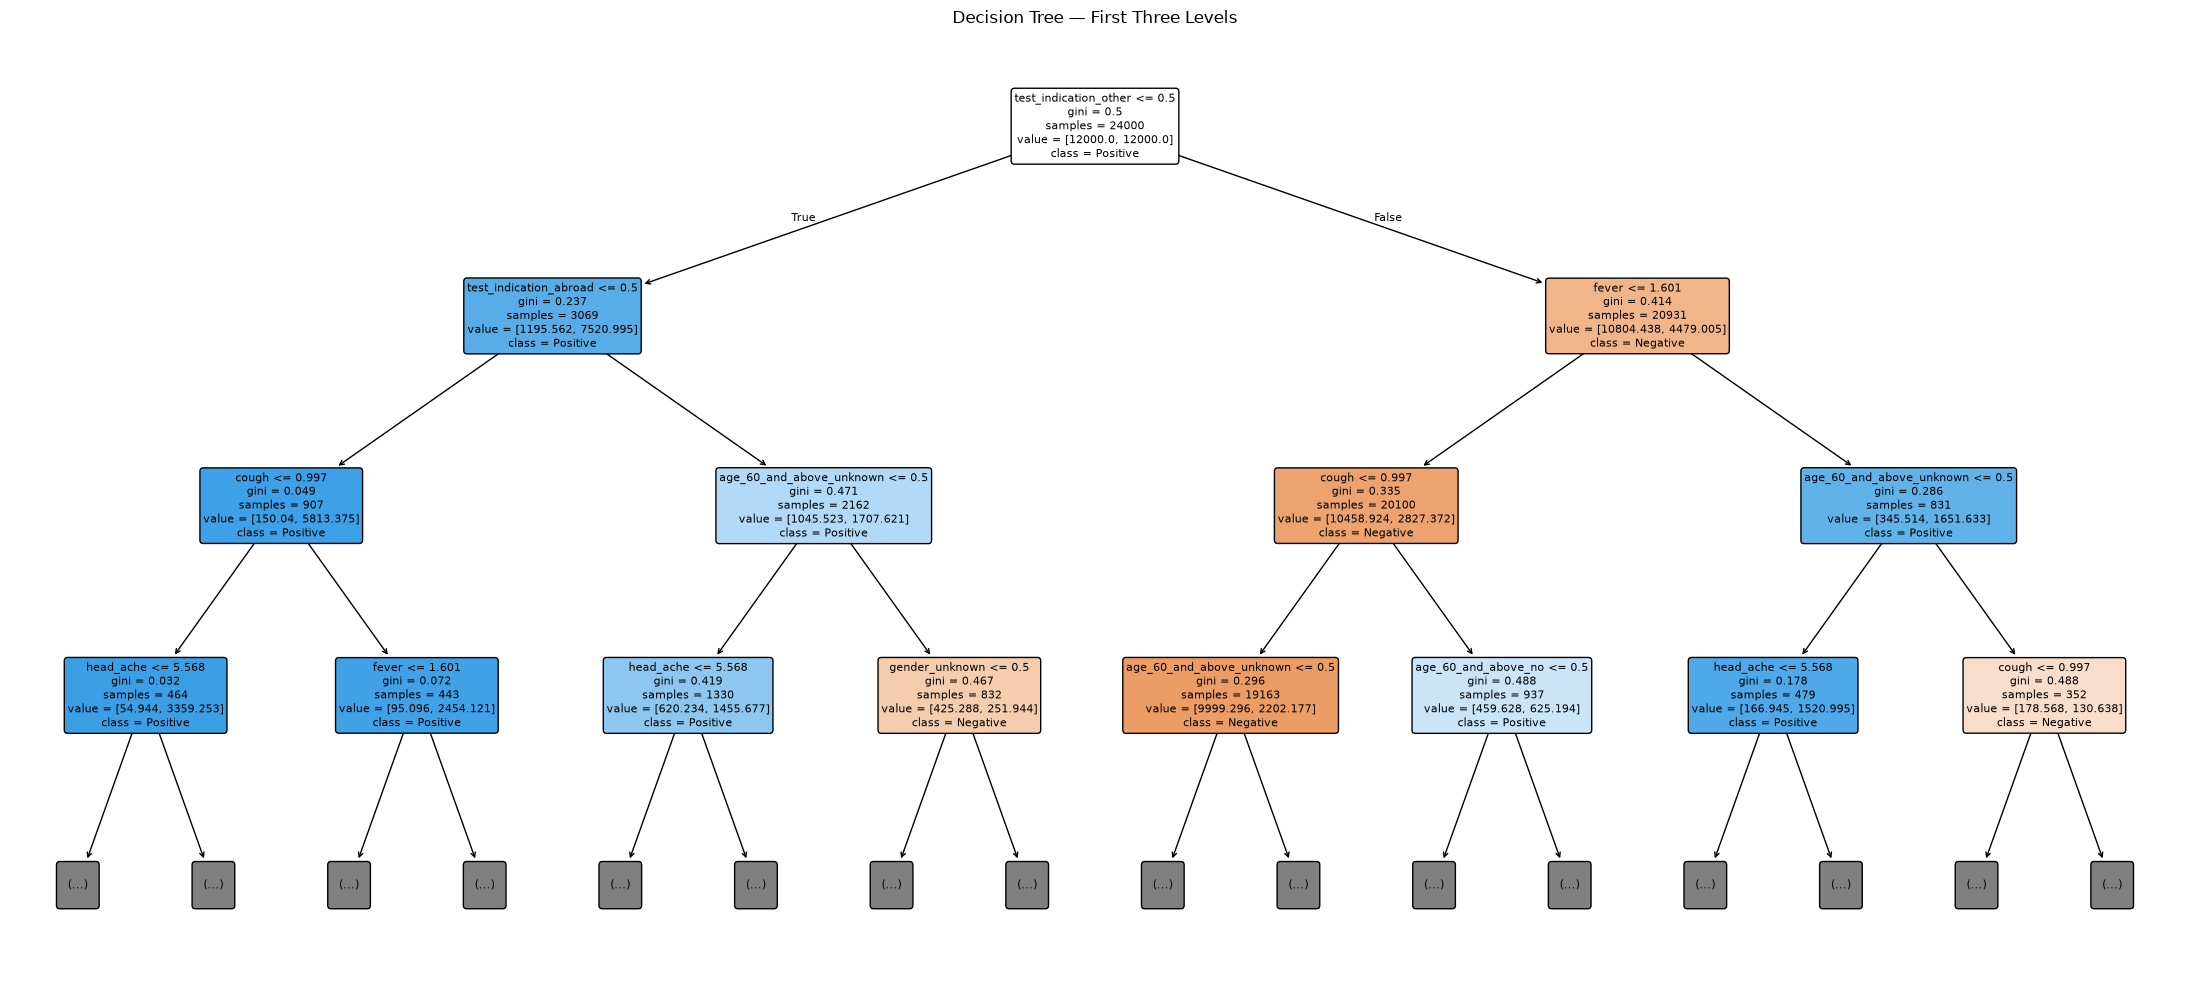

In [26]:
tree_pipeline = trained_models["Decision Tree"]
tree_feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
tree_model = tree_pipeline.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Negative", "Positive"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree — First Three Levels")
plt.tight_layout()
plt.show()

## 20. Random Forest Feature Importance

Random Forest feature importance shows which transformed predictors contributed most to the model's decisions.

In [27]:
forest_pipeline = trained_models["Random Forest"]
forest_feature_names = forest_pipeline.named_steps["preprocessor"].get_feature_names_out()
forest_importances = forest_pipeline.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": forest_feature_names,
        "importance": forest_importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

feature_importance

,feature,importance
13,test_indication_other,0.281006
12,test_indication_contact with confirmed,0.261899
1,fever,0.141415
0,cough,0.090137
6,age_60_and_above_unknown,0.040976
4,head_ache,0.040757
11,test_indication_abroad,0.040115
2,sore_throat,0.030842
3,shortness_of_breath,0.018261
5,age_60_and_above_no,0.015044


### Feature Importance Findings

The Random Forest relies most heavily on the reason for testing. The encoded `other` and `contact with confirmed` test-indication categories account for the two largest importance values, approximately 0.281 and 0.262.

Among the symptom variables, fever is the strongest contributor at approximately 0.141, followed by cough at approximately 0.090. Headache, sore throat, and shortness of breath contribute smaller but still visible amounts.

Feature importance describes how the fitted Random Forest used the predictors. It does not establish that any feature causes a positive test result.

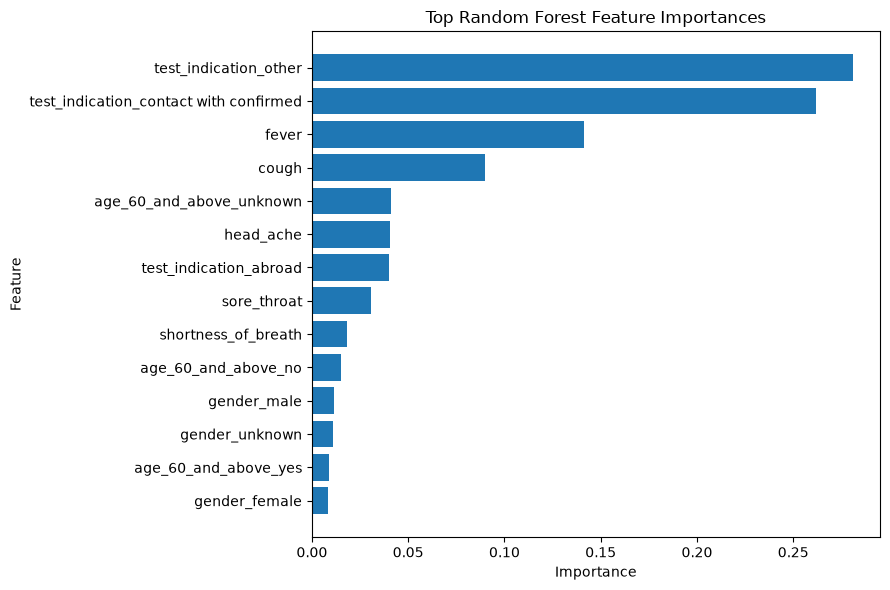

In [28]:
importance_plot = feature_importance.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 21. Final Model Selection

F1-score is used as the main selection metric because it balances the reliability of positive predictions with the proportion of positive cases detected.

Under this criterion, k-NN is selected as the final model with an F1-score of 0.6737. It achieves 0.7764 precision, 0.5950 recall, 0.9692 accuracy, and 0.9903 specificity.

Random Forest remains an important alternative because it reaches 0.8536 recall and detects more positive cases. The final choice therefore depends on the priority: k-NN gives the strongest precision-recall balance, while Random Forest favors positive-case detection.

In [29]:
best_model_name = results_df["F1"].idxmax()
best_result = results_df.loc[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Accuracy: {best_result['Accuracy']:.4f}")
print(f"Balanced accuracy: {best_result['Balanced Accuracy']:.4f}")
print(f"Precision: {best_result['Precision']:.4f}")
print(f"Recall: {best_result['Recall']:.4f}")
print(f"Specificity: {best_result['Specificity']:.4f}")
print(f"F1-score: {best_result['F1']:.4f}")
print(f"ROC-AUC: {best_result['ROC-AUC']:.4f}")
print(f"PR-AUC: {best_result['PR-AUC']:.4f}")

Selected model: k-NN
Accuracy: 0.9692
Balanced accuracy: 0.7927
Precision: 0.7764
Recall: 0.5950
Specificity: 0.9903
F1-score: 0.6737
ROC-AUC: 0.9081
PR-AUC: 0.6758


## 22. Conclusion

The four classifiers produced clearly different results on the COVID-19 individual testing dataset.

The majority-class baseline reached 94.65% accuracy but failed to detect any positive cases, confirming that accuracy alone is not suitable for this comparison.

k-NN achieved the highest F1-score at 0.6737, with 0.7764 precision and 0.5950 recall. It was selected as the final model because F1-score was defined as the main evaluation metric. Its high specificity of 0.9903 also shows that it produced relatively few false positive predictions.

Random Forest detected the largest proportion of positive cases, reaching 0.8536 recall, and achieved the strongest balanced accuracy and PR-AUC. Its lower precision shows that this improvement came with more false positive predictions.

The final result is therefore not that one classifier is best in every way. k-NN provides the strongest balance between positive-class precision and recall, while Random Forest is more suitable when missing positive cases is considered the greater cost.

These findings apply to the selected features, the reproducible 30,000-record sample, and the fixed train-test split used in this notebook. They describe model performance on this dataset and do not represent a clinical diagnosis system.